# Zomato Bangalore: Restaurant Ratings & Value Analysis

## The business story
Imagine you're advising someone opening a restaurant in Bangalore — or Zomato itself on which areas/cuisines to push. This analysis answers:

1. **Which areas of Bangalore have the highest-rated restaurants?**
2. **Does spending more mean eating better?** (price vs rating)
3. **Dine-in vs delivery:** do the same restaurants rate differently across the two?
4. **Which cuisines dominate Bangalore, and which are actually loved?**

Dataset: 8,923 Zomato restaurant listings, Bangalore (2022). File: `../data/zomato_bangalore.csv`

---
## 1. Load & inspect the data

Load the CSV with pandas. Then answer for yourself: how many rows/columns? What does each column mean? Which columns are numbers, which are text? Any obvious junk?

In [60]:
import pandas as pd
import numpy as np
df= pd.read_csv('zomato_bangalore.csv')
df.head()

,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,isVegOnly,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,"South Indian, North Indian, Chinese, Street Fo...","Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,1,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450
1,Meghana Foods,https://www.zomato.com/bangalore/meghana-foods...,"Biryani, Andhra, North Indian, Seafood","Indiranagar, Bangalore",Opens at 6:30pm,"544, First Floor, CMH Road, Near Indiranagar M...",+918041135050,1,1,1,0,4.3,1654,4.3,28600,Spicy Chicken Biryani,"Authentic Hyderabadi Biryani, Paneer Biryani, ...","Boneless Chicken Biryani, Ample Seating Area, ...",700
2,Donne Biriyani House,https://www.zomato.com/bangalore/donne-biriyan...,Biryani,"Indiranagar, Bangalore",11am – 11pm (Today),"8/ 9, 17th F Cross, 2nd Stage, Indiranagar, Ba...",+918861564169,1,1,1,0,3.9,411,3.5,33200,NaN,NaN,"Great Recommendations, Nice Taste, Great Ambia...",300
3,Domino's Pizza,https://www.zomato.com/bangalore/dominos-pizza...,"Pizza, Fast Food, Desserts","Indiranagar, Bangalore",10:57am – 12midnight (Today),"308, 2nd Stage, 100 Feet Road, Indiranagar, Ba...",+919916465787,1,1,1,0,2.4,422,4.4,8205,NaN,"Barbeque Chicken Pizza, Choco Lava Cake, White...","Value for Money, Packaging, Staff, Ambience, Food",400
4,KFC,https://www.zomato.com/bangalore/kfc-indiranagar,"Burger, Fast Food, Biryani, Desserts, Beverages","Indiranagar, Bangalore",11am – 11pm (Today),"38/1A, CMH Road, Indiranagar, Bangalore",+919513700040,1,1,1,0,2.8,673,4.0,9148,NaN,"Fiery Chicken, Chicken Popcorn, Rice Bowl, Wings","Elegantly Decorated, Great Recommendations, Vi...",400


---
## 2. Data cleaning

Real data is never clean. Hunt for these and fix them:

- **Duplicates** — are any restaurants listed twice?
- **Missing values** — which columns have nulls? Which ones matter for our questions, and which can we ignore?
- **Data types** — are the rating columns actually numeric? Is `AverageCost` numeric?
- **Sanity** — any impossible values? (e.g. ratings outside 0–5)

Decide and document each choice: *what* you did and *why*. Interviewers love this part.

In [5]:
# Your code here: clean the data
# Tip: check df.duplicated().sum(), df.isnull().sum(), df.dtypes
df.duplicated().sum()


np.int64(0)

In [85]:
missing = pd.DataFrame({
    "missing_count" : df.isna().sum(),
    "missing_percentage" : (df.isna().mean())*100
})
display = (missing[missing['missing_percentage']>0].sort_values("missing_percentage",ascending = False))
display

,missing_count,missing_percentage
KnownFor,8665,97.108596
PopularDishes,7388,82.797265
PeopleKnownFor,5439,60.954836
Dinner Ratings,5325,59.677239
Timing,3103,34.775300
Delivery Ratings,1131,12.675109


In [66]:


print(df["Dinner Ratings"].value_counts().head(15))


print(df["Delivery Ratings"].value_counts(dropna=False).head(15))


Dinner Ratings
3.9    335
3.8    333
3.7    324
4.0    279
3.6    270
4.1    230
3.5    229
3.2    187
3.4    184
3.3    179
4.2    166
3.1    163
3.0    122
4.3    110
2.9     91
Name: count, dtype: int64
Delivery Ratings
4.0    1441
NaN    1131
3.9     896
4.1     857
3.8     758
4.2     679
3.7     659
4.3     541
3.6     484
3.5     392
3.4     283
3.3     184
4.4     182
3.2     123
3.1     101
Name: count, dtype: int64


In [67]:
rating_cols = ["Delivery Ratings", "Dinner Ratings"]

for col in rating_cols:
    df[col] = pd.to_numeric(
    df[col].replace("-",np.nan))
    
print(df[rating_cols].dtypes)

Delivery Ratings    float64
Dinner Ratings      float64
dtype: object


In [69]:
print(df[rating_cols].isnull().sum())

print(df[rating_cols].describe())


Delivery Ratings    1131
Dinner Ratings      5325
dtype: int64
       Delivery Ratings  Dinner Ratings
count       7792.000000     3598.000000
mean           3.879197        3.645525
std            0.320969        0.474745
min            2.400000        2.000000
25%            3.700000        3.300000
50%            3.900000        3.700000
75%            4.100000        4.000000
max            4.700000        4.900000


In [82]:

for col in ["Dinner Ratings", "Delivery Ratings"]:
    invalid = df[col].notna() & ~df[col].between(0, 5)

    print(f"\n{col}")
    print("Invalid rating count:", invalid.sum())
    print(df.loc[invalid, [col]].head())



Dinner Ratings
Invalid rating count: 0
Empty DataFrame
Columns: [Dinner Ratings]
Index: []

Delivery Ratings
Invalid rating count: 0
Empty DataFrame
Columns: [Delivery Ratings]
Index: []


In [86]:
df

,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,isVegOnly,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,"South Indian, North Indian, Chinese, Street Fo...","Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,1,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450
1,Meghana Foods,https://www.zomato.com/bangalore/meghana-foods...,"Biryani, Andhra, North Indian, Seafood","Indiranagar, Bangalore",Opens at 6:30pm,"544, First Floor, CMH Road, Near Indiranagar M...",+918041135050,1,1,1,0,4.3,1654,4.3,28600,Spicy Chicken Biryani,"Authentic Hyderabadi Biryani, Paneer Biryani, ...","Boneless Chicken Biryani, Ample Seating Area, ...",700
2,Donne Biriyani House,https://www.zomato.com/bangalore/donne-biriyan...,Biryani,"Indiranagar, Bangalore",11am – 11pm (Today),"8/ 9, 17th F Cross, 2nd Stage, Indiranagar, Ba...",+918861564169,1,1,1,0,3.9,411,3.5,33200,NaN,NaN,"Great Recommendations, Nice Taste, Great Ambia...",300
3,Domino's Pizza,https://www.zomato.com/bangalore/dominos-pizza...,"Pizza, Fast Food, Desserts","Indiranagar, Bangalore",10:57am – 12midnight (Today),"308, 2nd Stage, 100 Feet Road, Indiranagar, Ba...",+919916465787,1,1,1,0,2.4,422,4.4,8205,NaN,"Barbeque Chicken Pizza, Choco Lava Cake, White...","Value for Money, Packaging, Staff, Ambience, Food",400
4,KFC,https://www.zomato.com/bangalore/kfc-indiranagar,"Burger, Fast Food, Biryani, Desserts, Beverages","Indiranagar, Bangalore",11am – 11pm (Today),"38/1A, CMH Road, Indiranagar, Bangalore",+919513700040,1,1,1,0,2.8,673,4.0,9148,NaN,"Fiery Chicken, Chicken Popcorn, Rice Bowl, Wings","Elegantly Decorated, Great Recommendations, Vi...",400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8918,New SBFC Food Funda,https://www.zomato.com/bangalore/new-sbfc-food...,Fast Food,"Frazer Town, Bangalore",4:30pm – 11:45pm (Today),"667/1, 9th Cross, Periyan Nagar, Devara Jeevan...",+916291201792,1,1,1,0,3.7,14,4.0,48,NaN,NaN,"Cheap and Affordable, Served Quickly, Fresh Fo...",300
8919,Kudla - Coraltree,https://www.zomato.com/bangalore/kudla-coraltr...,"Seafood, Mangalorean, Beverages","Coraltree, RT Nagar, Bangalore",12noon – 10pm (Today),"Coraltree, 16, MLA Layout, RT Nagar Main Road,...",+917760978681,1,1,0,0,3.9,348,4.3,564,NaN,"Neer Dosa, Chicken Ghee Roast, Seafood, Crab, ...","Authentic, Cashless Payments, Preparation, Dec...",1200
8920,Bangkok Bowl,https://www.zomato.com/bangalore/bangkok-bowl-...,"Salad, Chinese","Kammanahalli, Bangalore","12noon – 3pm, 6:30pm – 10pm (Today)","403, 3A Cross, Mariayappa Road, Kammanahalli, ...",+919739999170,1,1,0,0,NaN,0,3.7,254,NaN,NaN,"Contactless Delivery, Portion, Great Portions,...",300
8921,Yuan Restaurant,https://www.zomato.com/bangalore/yuan-restaura...,"Thai, Chinese","HBR Layout, Bangalore",Opens at 7pm,"2&3, Renu Arcade, 1st Stage, 2nd Block, 80 Fee...",+919901047070,1,1,1,0,3.8,188,3.5,3169,NaN,NaN,"Calm, Prompt Service, Portions, Spicy, Delicio...",400


---
## 3. Analysis

### Q1. Which areas have the highest-rated restaurants?

Group by `Area`, take the mean of `Dinner Ratings`. But be careful: an area with 2 restaurants averaging 4.5 means less than an area with 200 averaging 4.3. Set a minimum restaurant count to keep it fair. Visualise the top 10 as a bar chart.

In [119]:
from numpy import mean
# Your code here: Q1 — best areas by average dinner rating
area_analysis= (df.groupby("Area").agg(
                            avg_dinner_rating = ("Dinner Ratings", "mean"),
                            rated_restaurants = ("Dinner Ratings", "count")
).reset_index()
)
area_analysis = area_analysis[area_analysis["rated_restaurants"] >10]

area_analysis = area_analysis.sort_values(
    "avg_dinner_rating", ascending=False
)
area_analysis.head(10)

,Area,avg_dinner_rating,rated_restaurants
144,"St. Marks Road, Bangalore",3.978571,14
127,"Residency Road, Bangalore",3.952941,17
92,"Koramangala 6th Block, Bangalore",3.935714,28
91,"Koramangala 5th Block, Bangalore",3.934328,67
93,"Koramangala 7th Block, Bangalore",3.920588,34
27,"Church Street, Bangalore",3.915000,20
90,"Koramangala 4th Block, Bangalore",3.884211,19
70,"Indiranagar, Bangalore",3.874843,159
99,"Lavelle Road, Bangalore",3.857143,14
87,"Koramangala 1st Block, Bangalore",3.832000,25


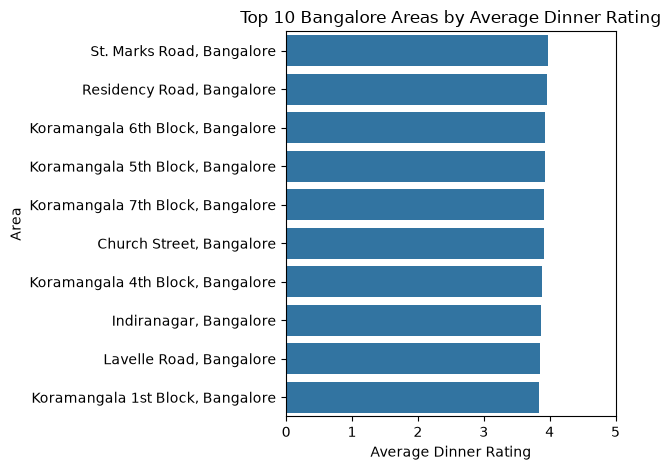

In [129]:
import matplotlib.pyplot as plt 
import seaborn as sns

top_areas = area_analysis.sort_values(
    "avg_dinner_rating",ascending=False
).head(10)


sns.barplot(
    data=top_areas,
    x="avg_dinner_rating",
    y="Area"
)

plt.title("Top 10 Bangalore Areas by Average Dinner Rating")
plt.xlabel("Average Dinner Rating")
plt.ylabel("Area")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

Among Bangalore areas with at least 10 restaurants having available dinner ratings, St. Marks Road had the highest average dinner rating (approximately 3.98), followed by Residency Road (3.95) and Koramangala 6th Block (3.94). Indiranagar had a slightly lower average of 3.87 across 159 rated restaurants, providing a larger sample for comparison.


In [139]:
df.columns

Index(['Name', 'URL', 'Cuisines', 'Area', 'Timing', 'Full_Address',
       'PhoneNumber', 'IsHomeDelivery', 'isTakeaway', 'isIndoorSeating',
       'isVegOnly', 'Dinner Ratings', 'Dinner Reviews', 'Delivery Ratings',
       'Delivery Reviews', 'KnownFor', 'PopularDishes', 'PeopleKnownFor',
       'AverageCost'],
      dtype='str')

### Q2. Does spending more mean eating better?

Plot `AverageCost` against `Dinner Ratings` (scatter). Compute the correlation. Then bin restaurants into price bands (Budget / Mid / Premium) and compare average ratings per band. Is expensive food actually better — or are there hidden gems?

In [182]:
initial = df[["AverageCost","Dinner Ratings"]].sort_values("Dinner Ratings",ascending=False)

In [183]:
initial.shape

(8923, 2)

In [166]:
filtered_spending = df[["AverageCost","Dinner Ratings"]].dropna()

In [185]:
filtered_spending.head(5)

,AverageCost,Dinner Ratings
0,450,4.0
1,700,4.3
2,300,3.9
3,400,2.4
4,400,2.8


In [181]:
filtered_spending.shape

(3598, 2)

In [189]:
filtered_spending["AverageCost"].corr(filtered_spending["Dinner Ratings"])

np.float64(0.37633505332258255)

<function matplotlib.pyplot.show(close=None, block=None)>

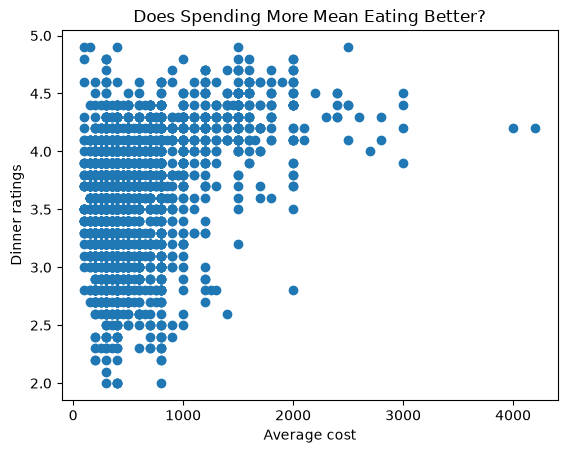

In [195]:
import matplotlib.pyplot as plt

plt.scatter(
    filtered_spending["AverageCost"],
    filtered_spending["Dinner Ratings"]
)
plt.title("Does Spending More Mean Eating Better?")
plt.xlabel("Average cost")
plt.ylabel("Dinner ratings")
plt.show

In [196]:
filtered_spending["AverageCost"].describe()

count    3598.000000
mean      539.091162
std       389.615098
min       100.000000
25%       300.000000
50%       400.000000
75%       650.000000
max      4200.000000
Name: AverageCost, dtype: float64

In [198]:
filtered_spending["PriceCategory"] = pd.cut(
    filtered_spending["AverageCost"],
    bins=[-float("inf"), 300, 650, float("inf")],
    labels=["Budget", "Mid-range", "Premium"]
)

In [199]:
filtered_spending["PriceCategory"].value_counts()

PriceCategory
Mid-range    1597
Budget       1117
Premium       884
Name: count, dtype: int64

In [200]:
filtered_spending.groupby("PriceCategory")["Dinner Ratings"].mean()

PriceCategory
Budget       3.547449
Mid-range    3.563870
Premium      3.916968
Name: Dinner Ratings, dtype: float64

Business conclusion: Premium restaurants have the highest average dinner rating (3.92), compared with 3.55 for Budget and 3.56 for Mid-range restaurants. Combined with the positive cost-rating correlation of 0.376, this suggests that higher-cost restaurants tend to receive better ratings in this dataset. However, price alone doesn't guarantee a better experience.


### Q3. Dine-in vs delivery: the service gap

Compare `Dinner Ratings` with `Delivery Ratings` for the same restaurants. On average, which is higher? Plot the distribution of the *difference*. Pick a few extreme examples — restaurants loved for dine-in but weak on delivery (or vice versa). What might explain it?

In [ ]:
# Your code here: Q3 — dinner vs delivery ratings

### Q4. Cuisines: most common vs most loved

The `Cuisines` column has comma-separated values — split and explode it first. Then: which cuisines appear most often (supply)? Which have the highest average rating (love)? A cuisine that's rare but highly rated is an opportunity; one that's everywhere but mediocre is a warning.

In [ ]:
# Your code here: Q4 — cuisine supply vs love

---
## 4. Key findings

Write 4–5 findings in **business language** — each with the finding and the *so what*. Example format:

- **Finding:** …  
  **So what:** …

No jargon, no 'the correlation coefficient is 0.38'. Write like you're advising the person opening the restaurant.